In [1]:
from sklearn.model_selection import train_test_split
from config import DATA_DIR, RESULTS_DIR, FIGURS_DIR, METADATA_DIR,EXPERIMENTS
import pandas as pd
import numpy as np
from util import compute_class_weights_effective_num, create_or_load_splits
from pathlib import Path
import SimpleITK as sitk
from monai.networks.nets import DenseNet121, resnet10, resnet18, SEResNet50
from torch.utils.data import DataLoader
from model import Small3DCNN,ImagingCNNClassifier
import torch.optim as optim
from adni_data import ADNIDataset
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from sklearn.preprocessing import label_binarize
import torch.nn as nn
import torch
from tqdm import tqdm
import os
import monai.transforms as mt
import argparse

/home/ybrima/miniconda3/envs/mxai/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ==============================================================================
# 1. LOAD DATA
# ==============================================================================
df_processed = pd.read_csv(Path(RESULTS_DIR, "ADNI_Combined_Multimodal_FIXED.csv"))

# CLASSES = df_processed['Group'].unique().tolist()
# CLASSES = df_processed["label_encoder"].classes_


# ==============================================================================
# 2. TRAIN / VAL / TEST SPLIT  (grouped by subject to prevent data leakage)
# ==============================================================================
# ==============================================================================
# CONFIGURATION
# ==============================================================================
# None -> use all classes
# ["CN", "AD"] -> binary experiment
# ["CN", "MCI"] -> binary experiment
# ["MCI", "AD"] -> binary experiment

# parser = argparse.ArgumentParser(description="Train ADNI Tabular Classifier")

# parser.add_argument(
#     "--experiment",
#     "-e",
#     type=int,
#     default=0,
#     choices=EXPERIMENTS.keys(),
#     help="""
# 0 = CN/MCI/AD (default)
# 1 = CN vs AD
# 2 = CN vs MCI
# 3 = MCI vs AD
# """,
# )


# args = parser.parse_args()

selected_classes = EXPERIMENTS[0]

print(f"Running experiment {0}")
print(f"Selected classes: {selected_classes or 'All classes'}")

# Three-class experiment (default)
train_df, val_df, test_df, suffix = create_or_load_splits(
    df_processed,
    RESULTS_DIR,
    selected_classes=selected_classes,
)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")


# ==============================================================================
# 3. DATASETS & DATALOADERS
# ==============================================================================
CLASSES = train_df['Group'].unique().tolist()



# import monai.transforms as mt

# --- TRAINING TRANSFORMS (Purely Geometric & Safe for Z-Score) ---
train_transform = mt.Compose([
    # Combats orientation and viewpoint memorization
    mt.RandFlip(prob=0.5, spatial_axis=0),             # Left/Right flip
    mt.RandFlip(prob=0.5, spatial_axis=1),             # Anterior/Posterior flip
    
    # Combats positioning and size memorization
    mt.RandAffine(
        prob=0.5, 
        rotate_range=(0.26, 0.26, 0.26),               # Up to ~15 degrees
        scale_range=(0.1, 0.1, 0.1),                   # Scale change +/- 10%
        mode="bilinear"
    ),
    
    # Combats brain shape memorization via local warping
    mt.Rand3DElastic(
        prob=0.2, 
        sigma_range=(5, 7), 
        magnitude_range=(50, 150), 
        mode="bilinear"
    )
])

# --- VALIDATION TRANSFORMS ---
val_transform = None

train_ds = ADNIDataset(train_df, CLASSES=CLASSES,transform=train_transform)
val_ds   = ADNIDataset(val_df,   CLASSES=CLASSES,transform=val_transform)
test_ds  = ADNIDataset(test_df,  CLASSES=CLASSES, transform=val_transform)


DEBUG_SAMPLES = 200  # start with 100–200
n_bootstrap = 1000
# train_df = train_df.sample(n=DEBUG_SAMPLES, random_state=42)


batch_size = 16

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,           # Essential: prevents learning sample order
    num_workers=4,
    pin_memory=False,
)
val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=False,
)
test_loader = DataLoader(
    test_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=False,
)

# Sanity check
images, labels = next(iter(train_loader))
print(f"Batch Image Shape: {images.shape}")   # Expect: [B, 1, D, H, W]
print(f"Batch Label Shape: {labels.shape}")   # Expect: [B]
print(f"Sample Labels:     {labels}")


Running experiment 0
Selected classes: All classes
Loading existing splits...
Train: 4639 | Val: 492 | Test: 480
Batch Image Shape: torch.Size([16, 1, 128, 128, 128])
Batch Label Shape: torch.Size([16])
Sample Labels:     tensor([1, 1, 1, 0, 1, 1, 1, 2, 1, 2, 1, 0, 1, 1, 0, 2])


In [9]:
# CLASSES, train_ds.label_map

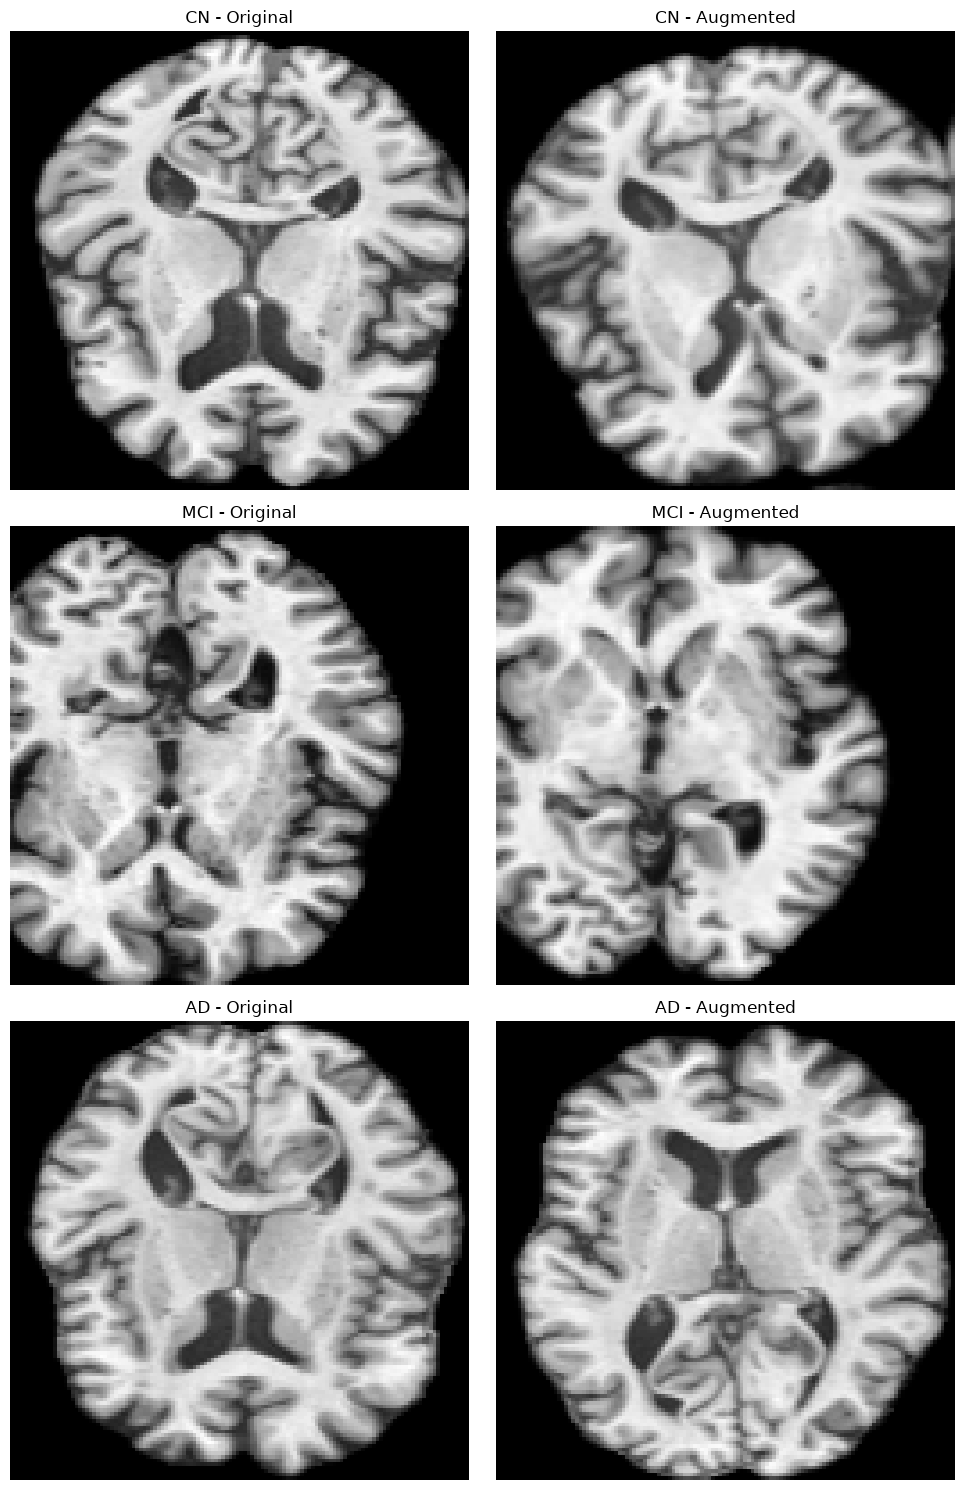

In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np

def plot_transform_effects(dataframe, CLASSES, train_transform):
    # Instantiate the dataset without transforms to get the raw base images
    base_dataset = ADNIDataset(dataframe, CLASSES, transform=None)
    
    # Dictionary to hold one sample index per class
    class_samples = {}
    for idx in range(len(base_dataset)):
        _, label_tensor = base_dataset[idx]
        label_idx = label_tensor.item()
        class_name = CLASSES[label_idx]
        
        if class_name not in class_samples:
            class_samples[class_name] = idx
        if len(class_samples) == len(CLASSES):
            break  # Found a sample for every class

    # Setup the plot grid: Rows = Classes, Columns = Original vs Augmented
    num_classes = len(CLASSES)
    fig, axes = plt.subplots(num_classes, 2, figsize=(10, 5 * num_classes))
    
    # Force axes to be a 2D array if there is only 1 class
    if num_classes == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, class_name in enumerate(CLASSES):
        sample_idx = class_samples[class_name]
        
        # 1. Get the original tensor
        orig_tensor, _ = base_dataset[sample_idx]
        
        # 2. Manually apply the transform to see its exact effect
        aug_tensor = train_transform(orig_tensor) if train_transform else orig_tensor
        
        # 3. Convert tensors to numpy arrays for plotting
        orig_arr = orig_tensor.squeeze().numpy()  # Shape: (128, 128, 128)
        aug_arr = aug_tensor.squeeze().numpy()    # Shape: (128, 128, 128)
        
        # 4. Extract the middle axial slice (Z-axis center)
        mid_slice = 128 // 2
        orig_slice = orig_arr[mid_slice, :, :]
        aug_slice = aug_arr[mid_slice, :, :]
        
        # Plot Original
        axes[i, 0].imshow(orig_slice, cmap="gray")
        axes[i, 0].set_title(f"{class_name} - Original")
        axes[i, 0].axis("off")
        
        # Plot Augmented
        axes[i, 1].imshow(aug_slice, cmap="gray")
        axes[i, 1].set_title(f"{class_name} - Augmented")
        axes[i, 1].axis("off")
        
    plt.tight_layout()
    plt.show()

# --- Execution Example ---
# Assuming 'train_df' and your list of 'CLASSES' (e.g., ['CN', 'MCI', 'AD']) are defined:
plot_transform_effects(train_df, CLASSES, train_transform)
